# 06 · Feature Engineering & Preprocessing

**Difficulty:** Intermediate | **Time:** ~2.5 hours

Garbage in → Garbage out. This notebook turns raw data into ML-ready features.

## Table of Contents
1. Why Preprocessing?
2. Handling Missing Values (Imputation)
3. Encoding Categorical Variables
4. Feature Scaling
5. Feature Creation
6. Handling Outliers
7. Pipelines — Putting It All Together

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, RobustScaler,
                                    LabelEncoder, OneHotEncoder, OrdinalEncoder)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

# Raw messy dataset — like real-world data
np.random.seed(42)
n = 300
raw = pd.DataFrame({
    'Age'       : np.random.randint(20, 65, n).astype(float),
    'Income'    : np.random.randint(20000, 150000, n).astype(float),
    'Education' : np.random.choice(['High School','Bachelor','Master','PhD'], n),
    'City'      : np.random.choice(['Mumbai','Delhi','Bangalore','Chennai','Pune'], n),
    'Experience': np.random.randint(0, 40, n).astype(float),
    'Loan_Amount': np.random.randint(10000, 500000, n).astype(float),
    'Defaulted' : np.random.choice([0, 1], n, p=[0.75, 0.25])
})

# Introduce realistic issues
raw.loc[np.random.choice(n, 30, replace=False), 'Age']     = np.nan
raw.loc[np.random.choice(n, 25, replace=False), 'Income']  = np.nan
raw.loc[np.random.choice(n, 15, replace=False), 'Education'] = np.nan

# Introduce outliers
raw.loc[0, 'Income']     = 9999999
raw.loc[1, 'Loan_Amount'] = 99999999

print("Raw dataset:")
print(raw.head())
print(f"\nMissing values:\n{raw.isnull().sum()}")

Raw dataset:
    Age     Income    Education       City  Experience  Loan_Amount  Defaulted
0  58.0  9999999.0       Master       Pune         3.0     404966.0          0
1  48.0   119522.0     Bachelor      Delhi        21.0   99999999.0          0
2  34.0   106416.0     Bachelor     Mumbai         1.0      77957.0          0
3  62.0    90271.0  High School  Bangalore         9.0     115423.0          0
4  27.0    64064.0       Master  Bangalore         4.0     330197.0          0

Missing values:
Age            30
Income         25
Education      15
City            0
Experience      0
Loan_Amount     0
Defaulted       0
dtype: int64


## 1. Why Preprocessing?

In [2]:
# Show what happens when you skip preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Attempt to fit without preprocessing — will fail or give poor results
print("Without preprocessing:")
try:
    X_raw = raw.drop('Defaulted', axis=1)
    y = raw['Defaulted']
    LogisticRegression().fit(X_raw, y)
except Exception as e:
    print(f"  ERROR: {type(e).__name__}: {e}")
    print("  → This is why preprocessing is mandatory!")

Without preprocessing:
  ERROR: ValueError: could not convert string to float: 'Master'
  → This is why preprocessing is mandatory!


## 2. Handling Missing Values

Missing value strategies:



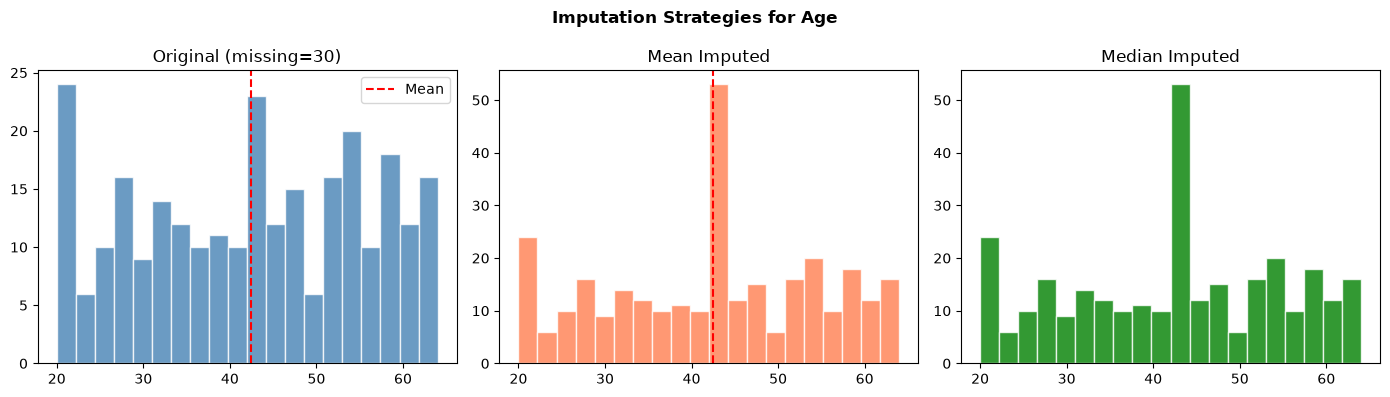

In [3]:
print("Missing value strategies:\n")

# Strategy 1: Mean/Median/Mode Imputation
imputer_mean   = SimpleImputer(strategy='mean')
imputer_median = SimpleImputer(strategy='median')

age_col = raw[['Age']]
mean_filled   = imputer_mean.fit_transform(age_col)
median_filled = imputer_median.fit_transform(age_col)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(raw['Age'].dropna(), bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title(f"Original (missing={raw['Age'].isna().sum()})")
axes[0].axvline(raw['Age'].mean(), color='red', ls='--', label='Mean')
axes[0].legend()

axes[1].hist(mean_filled.ravel(), bins=20, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title("Mean Imputed")
axes[1].axvline(np.nanmean(age_col), color='red', ls='--')

axes[2].hist(median_filled.ravel(), bins=20, color='green', edgecolor='white', alpha=0.8)
axes[2].set_title("Median Imputed")

plt.suptitle("Imputation Strategies for Age", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("/tmp/imputation.png", dpi=100)
plt.show()

In [4]:
# Strategy 2: KNN Imputation (smarter — uses similar rows)
knn_imputer = KNNImputer(n_neighbors=5)
numeric_cols = raw[['Age','Income','Experience','Loan_Amount']].copy()
knn_filled = pd.DataFrame(knn_imputer.fit_transform(numeric_cols), columns=numeric_cols.columns)

print("Before KNN imputation:")
print(numeric_cols.isnull().sum())
print("\nAfter KNN imputation:")
print(knn_filled.isnull().sum())
print("\nSample comparison (rows with Age was missing):")
missing_idx = raw[raw['Age'].isna()].index[:5]
print("Original Age:", raw.loc[missing_idx, 'Age'].values)
print("KNN filled:  ", knn_filled.loc[missing_idx, 'Age'].round(1).values)

Before KNN imputation:
Age            30
Income         25
Experience      0
Loan_Amount     0
dtype: int64

After KNN imputation:
Age            0
Income         0
Experience     0
Loan_Amount    0
dtype: int64

Sample comparison (rows with Age was missing):
Original Age: [nan nan nan nan nan]
KNN filled:   [50.6 37.  46.8 33.6 41. ]


## 3. Encoding Categorical Variables

In [5]:
# Method 1: Label Encoding (for ordinal data — has order)
# Education has a natural order: HS < Bachelor < Master < PhD
ordinal_enc = OrdinalEncoder(categories=[['High School','Bachelor','Master','PhD']])
raw_clean = raw.copy()
raw_clean['Education'] = raw_clean['Education'].fillna('Bachelor')  # fill missing first

edu_encoded = ordinal_enc.fit_transform(raw_clean[['Education']])
print("Ordinal Encoding (Education):")
print("  High School→0, Bachelor→1, Master→2, PhD→3")
for orig, enc in zip(['High School','Bachelor','Master','PhD'],
                     ordinal_enc.transform([['High School'],['Bachelor'],['Master'],['PhD']]).ravel()):
    print(f"  {orig:<15} → {enc}")

Ordinal Encoding (Education):
  High School→0, Bachelor→1, Master→2, PhD→3
  High School     → 0.0
  Bachelor        → 1.0
  Master          → 2.0
  PhD             → 3.0


In [6]:
# Method 2: One-Hot Encoding (for nominal data — no order)
# City has no natural order
ohe = OneHotEncoder(sparse_output=False, drop='first')  # drop first to avoid multicollinearity
city_encoded = ohe.fit_transform(raw_clean[['City']])
city_df = pd.DataFrame(city_encoded, columns=ohe.get_feature_names_out(['City']))
print("One-Hot Encoding (City):")
print(city_df.head(8))
print(f"\nOriginal: 1 column → OHE: {city_df.shape[1]} columns (drop='first' removes one)")

One-Hot Encoding (City):
   City_Chennai  City_Delhi  City_Mumbai  City_Pune
0           0.0         0.0          0.0        1.0
1           0.0         1.0          0.0        0.0
2           0.0         0.0          1.0        0.0
3           0.0         0.0          0.0        0.0
4           0.0         0.0          0.0        0.0
5           0.0         0.0          1.0        0.0
6           0.0         0.0          0.0        1.0
7           0.0         0.0          1.0        0.0

Original: 1 column → OHE: 4 columns (drop='first' removes one)


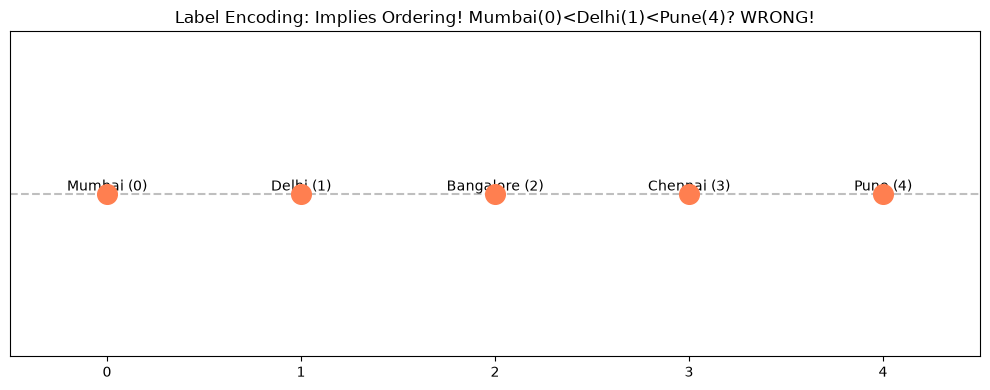

→ Use One-Hot Encoding for nominal (unordered) categories


In [7]:
# Comparison: why NOT use label encoding for City?
fig, ax = plt.subplots(figsize=(10, 4))

categories = ['Mumbai','Delhi','Bangalore','Chennai','Pune']
label_vals = [0, 1, 2, 3, 4]

# Show that label encoding implies order: Pune(4) > Mumbai(0)?
ax.scatter(label_vals, [1]*5, s=200, c='coral', zorder=5)
for i, (cat, val) in enumerate(zip(categories, label_vals)):
    ax.annotate(f"{cat} ({val})", (val, 1), ha='center', va='bottom', fontsize=10)
ax.set_xlim(-0.5, 4.5)
ax.set_title("Label Encoding: Implies Ordering! Mumbai(0)<Delhi(1)<Pune(4)? WRONG!")
ax.set_yticks([])
ax.axhline(1, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("/tmp/encoding_issue.png", dpi=100)
plt.show()
print("→ Use One-Hot Encoding for nominal (unordered) categories")

## 4. Feature Scaling

Feature ranges BEFORE scaling:
      Age     Income  Loan_Amount
min   0.0        0.0      12050.0
max  64.0  9999999.0   99999999.0


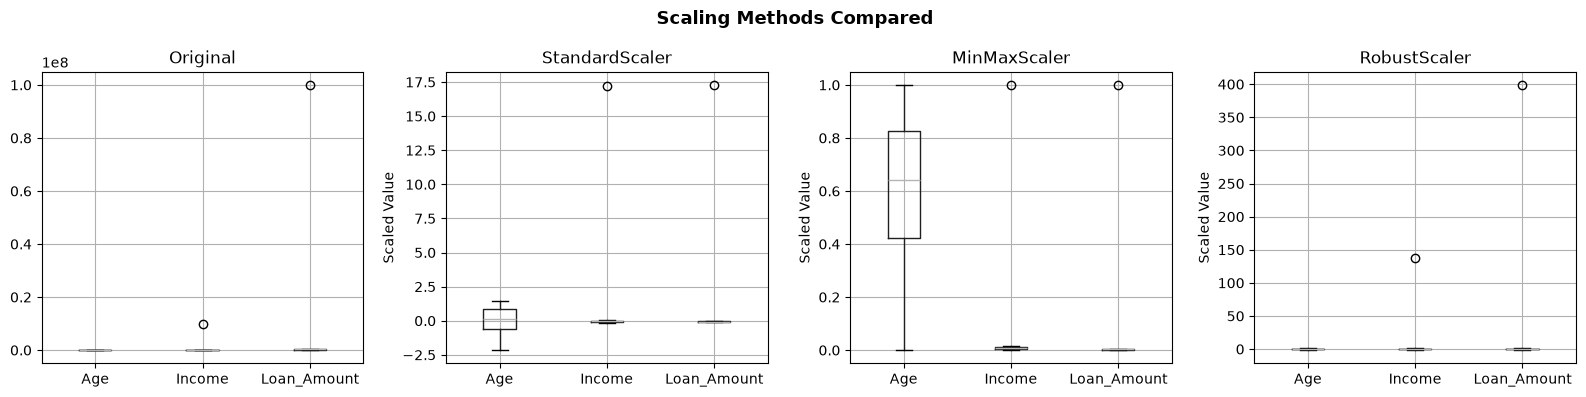

In [8]:
# Why scaling matters — demonstrate with a real example
raw_numeric = raw[['Age','Income','Loan_Amount']].fillna(0)
print("Feature ranges BEFORE scaling:")
print(raw_numeric.describe().loc[['min','max']].round(0))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

scalers = {
    'Original'      : raw_numeric,
    'StandardScaler': StandardScaler().fit_transform(raw_numeric),
    'MinMaxScaler'  : MinMaxScaler().fit_transform(raw_numeric),
    'RobustScaler'  : RobustScaler().fit_transform(raw_numeric),
}

for i, (name, data) in enumerate(scalers.items()):
    if isinstance(data, np.ndarray):
        data = pd.DataFrame(data, columns=raw_numeric.columns)
    data.boxplot(ax=axes[i])
    axes[i].set_title(name)
    if i > 0:
        axes[i].set_ylabel("Scaled Value")

plt.suptitle("Scaling Methods Compared", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/tmp/scaling.png", dpi=100)
plt.show()

In [9]:
print("When to use each scaler:\n")
print("StandardScaler (Z-score):")
print("  → Use when: Data is roughly normal, no extreme outliers")
print("  → Formula: (x - mean) / std   →   mean=0, std=1")
print()
print("MinMaxScaler (0 to 1):")
print("  → Use when: You need values between 0-1 (e.g., neural networks, images)")
print("  → Formula: (x - min) / (max - min)")
print()
print("RobustScaler (IQR-based):")
print("  → Use when: Data has many outliers")
print("  → Formula: (x - median) / IQR   →  not affected by extreme values")

When to use each scaler:

StandardScaler (Z-score):
  → Use when: Data is roughly normal, no extreme outliers
  → Formula: (x - mean) / std   →   mean=0, std=1

MinMaxScaler (0 to 1):
  → Use when: You need values between 0-1 (e.g., neural networks, images)
  → Formula: (x - min) / (max - min)

RobustScaler (IQR-based):
  → Use when: Data has many outliers
  → Formula: (x - median) / IQR   →  not affected by extreme values


## 5. Feature Creation

New features correlation with Defaulted:
DTI_Ratio        -0.038
Income_per_Exp   -0.024
Age_sq           -0.086
Name: Defaulted, dtype: float64


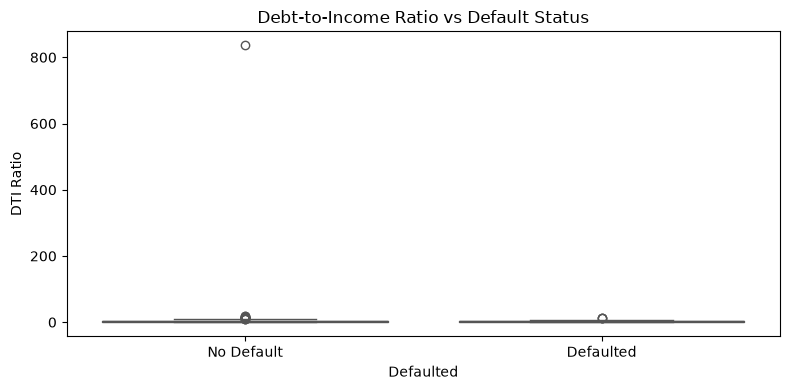

In [10]:
# Feature engineering from domain knowledge
df_fe = raw.copy()
df_fe['Age'].fillna(df_fe['Age'].median(), inplace=True)
df_fe['Income'].fillna(df_fe['Income'].median(), inplace=True)

# 1. Debt-to-Income ratio
df_fe['DTI_Ratio'] = df_fe['Loan_Amount'] / (df_fe['Income'] + 1)

# 2. Income per year of experience
df_fe['Income_per_Exp'] = df_fe['Income'] / (df_fe['Experience'] + 1)

# 3. Age group (binning)
df_fe['Age_Group'] = pd.cut(df_fe['Age'],
                             bins=[0, 30, 45, 65],
                             labels=['Young','Mid','Senior'])

# 4. Polynomial feature
df_fe['Age_sq'] = df_fe['Age'] ** 2

print("New features correlation with Defaulted:")
new_feats = ['DTI_Ratio','Income_per_Exp','Age_sq']
corr_vals = df_fe[new_feats + ['Defaulted']].corr()['Defaulted'].drop('Defaulted')
print(corr_vals.round(3))

# Visualize DTI vs default
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df_fe, x='Defaulted', y='DTI_Ratio', palette=['#4ECDC4','#FF6B6B'], ax=ax)
ax.set_xticklabels(['No Default','Defaulted'])
ax.set_title("Debt-to-Income Ratio vs Default Status")
ax.set_ylabel("DTI Ratio")
plt.tight_layout()
plt.savefig("/tmp/dti_default.png", dpi=100)
plt.show()

## 6. Handling Outliers

Income Q1=54890, Q3=118002, IQR=63112
Upper fence: 212671
Outliers: 1


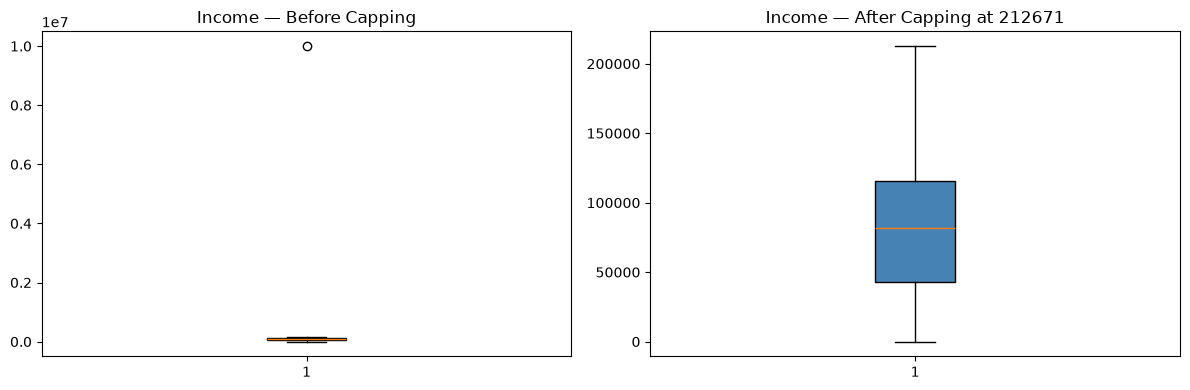

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Identify outliers
Q1 = raw['Income'].quantile(0.25)
Q3 = raw['Income'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR

print(f"Income Q1={Q1:.0f}, Q3={Q3:.0f}, IQR={IQR:.0f}")
print(f"Upper fence: {upper_fence:.0f}")
print(f"Outliers: {(raw['Income'] > upper_fence).sum()}")

# Before capping
axes[0].boxplot(raw['Income'].fillna(0), patch_artist=True, 
                boxprops=dict(facecolor='coral'))
axes[0].set_title("Income — Before Capping")

# Winsorizing (capping)
income_capped = raw['Income'].clip(upper=upper_fence)
axes[1].boxplot(income_capped.fillna(0), patch_artist=True,
                boxprops=dict(facecolor='steelblue'))
axes[1].set_title(f"Income — After Capping at {upper_fence:.0f}")

plt.tight_layout()
plt.savefig("/tmp/outlier_capping.png", dpi=100)
plt.show()

## 7. Pipeline — Production-Ready Preprocessing

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Clean dataset for pipeline demo
df_pipe = raw.copy()
df_pipe['Education'] = df_pipe['Education'].fillna('Bachelor')
df_pipe['Income']    = df_pipe['Income'].clip(upper=upper_fence)

X = df_pipe.drop('Defaulted', axis=1)
y = df_pipe['Defaulted']

# Define column groups
numeric_features     = ['Age','Income','Experience','Loan_Amount']
categorical_nominal  = ['City']
categorical_ordinal  = ['Education']

# Build sub-pipelines
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

nominal_pipe = Pipeline([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
])

ordinal_pipe = Pipeline([
    ('enc', OrdinalEncoder(categories=[['High School','Bachelor','Master','PhD']]))
])

# Combine with ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipe,  numeric_features),
    ('nom', nominal_pipe,  categorical_nominal),
    ('ord', ordinal_pipe,  categorical_ordinal),
])

# Full pipeline: preprocessing + model
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(max_iter=1000))
])

# Train and evaluate
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)

print("Pipeline Results:")
print(classification_report(y_test, y_pred, target_names=['No Default','Defaulted']))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")

Pipeline Results:
              precision    recall  f1-score   support

  No Default       0.77      1.00      0.87        46
   Defaulted       0.00      0.00      0.00        14

    accuracy                           0.77        60
   macro avg       0.38      0.50      0.43        60
weighted avg       0.59      0.77      0.67        60

Accuracy: 76.67%


## Summary

| Problem | Solution |
|---|---|
| Missing values | Mean/Median imputation or KNN |
| Categorical (ordered) | Ordinal Encoding |
| Categorical (unordered) | One-Hot Encoding |
| Different scales | StandardScaler / MinMaxScaler |
| Outliers | Winsorizing (clip) or RobustScaler |
| All together | sklearn Pipeline + ColumnTransformer |

**Next notebook →** `07_Linear_Regression.ipynb`